# Penguin Analysis

**Course:** BCB/EEOB 5460  
**Assignment:** Python workflow documentation and completion  

This notebook contains

1. Read cytochrome-b DNA sequences for 12 penguin species
2. Translate DNA sequences to amino acid sequences
3. Compute GC content for each DNA sequence
4. Compute molecular weight for each translated amino acid sequence
5. Add those values to a penguin body-mass DataFrame
6. Create required visualizations
7. Export the final results table

## Reproducibility notes

This notebook uses the required files in the 00_data_files folder [download through wget]:

- `sequence_translate.py`
- `penguins_mass.csv`
- `penguins_cytb.fasta`

This assumes BioPython and required packages are installed. If needed:

```bash
pip install biopython pandas matplotlib
```

**Download the required packages**


In [106]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO
from Bio.Data import CodonTable
from Bio.Seq import Seq
from Bio.SeqUtils.ProtParam import ProteinAnalysis

**Since this will use github as a preserved platform, after clone the github, we need to go the github reporsitory or ipynb can work on their own as well**

**_Please change this !!! if you replicate the repository_**

In [107]:
%cd ~/Downloads/Bamrung_EEOB5460_Spring2026
# please change the directory to where you have downloaded the repository or skip this

/Users/fan/Downloads/Bamrung_EEOB5460_Spring2026


create a directory to put all the working files in and this would help the code to run smmothly without further `cd` commands

In [108]:
%mkdir -p 00_data_files 01_python_assignment_key 03_output_files # please change the directory to where you have downloaded the repository or skip this

**Dowload the required files**

This code download files using `wget` command

In [109]:
!wget -P 00_data_files https://raw.githubusercontent.com/EEOB-BioData/BCB5460_Spring2026/main/assignments/Python/sequence_translate.py
!wget -P 00_data_files https://raw.githubusercontent.com/EEOB-BioData/BCB5460_Spring2026/main/assignments/Python/penguins_mass.csv
!wget -P 00_data_files https://raw.githubusercontent.com/EEOB-BioData/BCB5460_Spring2026/main/assignments/Python/penguins_cytb.fasta

--2026-04-26 02:00:03--  https://raw.githubusercontent.com/EEOB-BioData/BCB5460_Spring2026/main/assignments/Python/sequence_translate.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8001::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8381 (8.2K) [text/plain]
Saving to: ‘00_data_files/sequence_translate.py’

sequence_translate. 100%[===================>]   8.18K  --.-KB/s    in 0.003s  

2026-04-26 02:00:03 (3.18 MB/s) - ‘00_data_files/sequence_translate.py’ saved [8381/8381]

--2026-04-26 02:00:03--  https://raw.githubusercontent.com/EEOB-BioData/BCB5460_Spring2026/main/assignments/Python/penguins_mass.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8001::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubus

**Defien file paths of the workflow**
This define a path to the folders created earlier

In [110]:
from pathlib import Path

DATA_DIR = Path("00_data_files")
OUTPUT_DIR =  Path("03_output_files")

FASTA_FILE = DATA_DIR / "penguins_cytb.fasta"
MASS_FILE = DATA_DIR / "penguins_mass.csv"
SCRIPT_FILE = DATA_DIR / "sequence_translate.py"

# check if the files exist
print("FASTA:", FASTA_FILE.exists(), FASTA_FILE)
print("Mass CSV:", MASS_FILE.exists(), MASS_FILE)
print("Script:", SCRIPT_FILE.exists(), SCRIPT_FILE)

FASTA: True 00_data_files/penguins_cytb.fasta
Mass CSV: True 00_data_files/penguins_mass.csv
Script: True 00_data_files/sequence_translate.py


**Read body mass file and cytochrome-b file and Load the mass data into a DataFrame**

In [111]:
# Read the penguin body mass data
penguins_df = pd.read_csv(MASS_FILE)

penguins_df.head()

,species,mass
0,Aptenodytes forsteri,28.00
1,Aptenodytes patagonicus,13.40
2,Eudyptes chrysocome,2.80
3,Eudyptes chrysolophus,4.50
4,Eudyptes sclateri,4.25


In [112]:
# Read cytochrome-b DNA sequences from the FASTA file
cytb_seqs = {}

for record in SeqIO.parse(FASTA_FILE, "fasta"):
    species_name = record.description
    cytb_seqs[species_name] = record.seq

cytb_seqs

{'AB026282 Aptenodytes forsteri mitochondrial gene for cytochrome b, complete cds, haplotype:a': Seq('ATGGCCCCAAATCTCCGAAAATCCCATCCCCTCCTAAAAATAATTAATAACTCC...TAA'),
 'AF076044 Aptenodytes patagonicus cytochrome b (cytb) gene, mitochondrial gene encoding mitochondrial protein, complete cds': Seq('ATGGCCCCAAACCTCCGAAAATCCCATCCTCTCCTAAAAATAATTAATAACTCC...TAA'),
 'AF076051 Eudyptes chrysocome cytochrome b (cytb) gene, mitochondrial gene encoding mitochondrial protein, complete cds': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'),
 'AF076052 Eudyptes chrysolophus cytochrome b (cytb) gene, mitochondrial gene encoding mitochondrial protein, complete cds': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'),
 'AB026277 Eudyptes sclateri mitochondrial gene for cytochrome b, complete cds': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'),
 'AB026278 Eudyptula minor mitochondrial gene for cytochrome b, complete cds': Seq('ATGGCCCCCAACCTCCGA

In [113]:
# Check species names in both files
print("Species in mass file:")
print(penguins_df["species"].tolist())

print("\nSpecies in FASTA file:")
print(list(cytb_seqs.keys()))

Species in mass file:
['Aptenodytes forsteri', 'Aptenodytes patagonicus', 'Eudyptes chrysocome', 'Eudyptes chrysolophus', 'Eudyptes sclateri', 'Eudyptula minor', 'Pygoscelis adeliae', 'Pygoscelis antarctica', 'Pygoscelis papua', 'Spheniscus demersus', 'Spheniscus humboldti', 'Spheniscus magellanicus']

Species in FASTA file:
['AB026282 Aptenodytes forsteri mitochondrial gene for cytochrome b, complete cds, haplotype:a', 'AF076044 Aptenodytes patagonicus cytochrome b (cytb) gene, mitochondrial gene encoding mitochondrial protein, complete cds', 'AF076051 Eudyptes chrysocome cytochrome b (cytb) gene, mitochondrial gene encoding mitochondrial protein, complete cds', 'AF076052 Eudyptes chrysolophus cytochrome b (cytb) gene, mitochondrial gene encoding mitochondrial protein, complete cds', 'AB026277 Eudyptes sclateri mitochondrial gene for cytochrome b, complete cds', 'AB026278 Eudyptula minor mitochondrial gene for cytochrome b, complete cds', 'AB066603 Pygoscelis adeliae mitochondrial gen

**Add GC content column**

In [114]:
# Add empty columns for GC content and molecular weight
penguins_df["GC_content"] = None
penguins_df["molecular_weight"] = None

penguins_df

,species,mass,GC_content,molecular_weight
0,Aptenodytes forsteri,28.00,None,None
1,Aptenodytes patagonicus,13.40,None,None
2,Eudyptes chrysocome,2.80,None,None
3,Eudyptes chrysolophus,4.50,None,None
4,Eudyptes sclateri,4.25,None,None
5,Eudyptula minor,1.60,None,None
6,Pygoscelis adeliae,4.60,None,None
7,Pygoscelis antarctica,4.10,None,None
8,Pygoscelis papua,6.10,None,None
9,Spheniscus demersus,3.20,None,None


**Since the species name of the two files does not match I reformat the name**

In [115]:
cytb_seqs = {}

for record in SeqIO.parse(FASTA_FILE, "fasta"):
    description_parts = record.description.split()
    species_name = description_parts[1] + " " + description_parts[2]
    cytb_seqs[species_name] = record.seq

print(list(cytb_seqs.keys()))

['Aptenodytes forsteri', 'Aptenodytes patagonicus', 'Eudyptes chrysocome', 'Eudyptes chrysolophus', 'Eudyptes sclateri', 'Eudyptula minor', 'Pygoscelis adeliae', 'Pygoscelis antarctica', 'Pygoscelis papua', 'Spheniscus demersus', 'Spheniscus humboldti', 'Spheniscus magellanicus']


In [116]:
# Calculate GC content and molecular weight for each species

for index, row in penguins_df.iterrows():
    species = row["species"]
    
    dna_seq = cytb_seqs[species]
    
    # Calculate GC content
    dna_seq_str = str(dna_seq).upper()
    gc_count = dna_seq_str.count("G") + dna_seq_str.count("C")
    gc_content = (gc_count / len(dna_seq_str)) * 100
    
    # Translate DNA sequence to amino acid sequence
    aa_seq = dna_seq.translate(to_stop=True)
    aa_seq_str = str(aa_seq)
    
    # Calculate molecular weight
    protein_analysis = ProteinAnalysis(aa_seq_str)
    molecular_weight = protein_analysis.molecular_weight()
    
    # Store results in DataFrame
    penguins_df.loc[index, "GC_content"] = gc_content
    penguins_df.loc[index, "molecular_weight"] = molecular_weight

penguins_df

,species,mass,GC_content,molecular_weight
0,Aptenodytes forsteri,28.00,48.381452,3268.8268
1,Aptenodytes patagonicus,13.40,49.693788,3268.8268
2,Eudyptes chrysocome,2.80,51.181102,3256.7731
3,Eudyptes chrysolophus,4.50,50.918635,3256.7731
4,Eudyptes sclateri,4.25,50.831146,3256.7731
5,Eudyptula minor,1.60,49.256343,3298.8528
6,Pygoscelis adeliae,4.60,49.081365,3268.8268
7,Pygoscelis antarctica,4.10,47.769029,3268.8268
8,Pygoscelis papua,6.10,47.156605,3292.9344
9,Spheniscus demersus,3.20,48.293963,3256.7731


In [117]:
# Convert new columns to numeric
penguins_df["GC_content"] = pd.to_numeric(penguins_df["GC_content"])
penguins_df["molecular_weight"] = pd.to_numeric(penguins_df["molecular_weight"])

penguins_df

,species,mass,GC_content,molecular_weight
0,Aptenodytes forsteri,28.00,48.381452,3268.8268
1,Aptenodytes patagonicus,13.40,49.693788,3268.8268
2,Eudyptes chrysocome,2.80,51.181102,3256.7731
3,Eudyptes chrysolophus,4.50,50.918635,3256.7731
4,Eudyptes sclateri,4.25,50.831146,3256.7731
5,Eudyptula minor,1.60,49.256343,3298.8528
6,Pygoscelis adeliae,4.60,49.081365,3268.8268
7,Pygoscelis antarctica,4.10,47.769029,3268.8268
8,Pygoscelis papua,6.10,47.156605,3292.9344
9,Spheniscus demersus,3.20,48.293963,3256.7731


In [118]:
# add amino acid sequence column
penguins_df["amino_acid_sequence"] = None

for index, row in penguins_df.iterrows():
    species = row["species"]
    dna_seq = cytb_seqs[species]

    dna_seq_str = str(dna_seq).upper()
    gc_count = dna_seq_str.count("G") + dna_seq_str.count("C")
    gc_content = (gc_count / len(dna_seq_str)) * 100

    aa_seq = dna_seq.translate(to_stop=True)
    aa_seq_str = str(aa_seq)

    protein_analysis = ProteinAnalysis(aa_seq_str)
    molecular_weight = protein_analysis.molecular_weight()

    penguins_df.loc[index, "amino_acid_sequence"] = aa_seq_str
    penguins_df.loc[index, "GC_content"] = gc_content
    penguins_df.loc[index, "molecular_weight"] = molecular_weight

penguins_df

,species,mass,GC_content,molecular_weight,amino_acid_sequence
0,Aptenodytes forsteri,28.00,48.381452,3268.8268,MAPNLRKSHPLLKIINNSLIDLPTPSNISA
1,Aptenodytes patagonicus,13.40,49.693788,3268.8268,MAPNLRKSHPLLKIINNSLIDLPTPSNISA
2,Eudyptes chrysocome,2.80,51.181102,3256.7731,MAPNLRKSHPLLKTINNSLIDLPTPSNISA
3,Eudyptes chrysolophus,4.50,50.918635,3256.7731,MAPNLRKSHPLLKTINNSLIDLPTPSNISA
4,Eudyptes sclateri,4.25,50.831146,3256.7731,MAPNLRKSHPLLKTINNSLIDLPTPSNISA
5,Eudyptula minor,1.60,49.256343,3298.8528,MAPNLRKSHPLLKIINNSLIDLPTPSNIST
6,Pygoscelis adeliae,4.60,49.081365,3268.8268,MAPNLRKSHPLLKIINNSLIDLPTPSNISA
7,Pygoscelis antarctica,4.10,47.769029,3268.8268,MAPNLRKSHPLLKIINNSLIDLPTPSNISA
8,Pygoscelis papua,6.10,47.156605,3292.9344,MAPNLRKSHPLLKIINKSLIDLPTPPNISA
9,Spheniscus demersus,3.20,48.293963,3256.7731,MAPNLRKSHPLLKTINNSLIDLPTPSNISA


**Save the final df to the output folder**

In [119]:
# Save the final DataFrame
penguins_df.to_csv(OUTPUT_DIR / "penguins_final_results.csv", index=False)

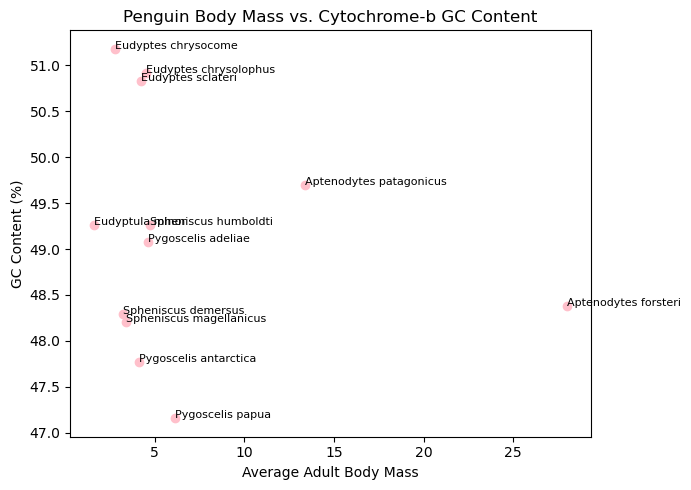

In [120]:
plt.figure(figsize=(7, 5))

plt.scatter(
    penguins_df["mass"],
    penguins_df["GC_content"],
    color="pink"
)

# Annotate each point with species name
for i in range(len(penguins_df)):
    plt.text(
        penguins_df["mass"][i],
        penguins_df["GC_content"][i],
        penguins_df["species"][i],
        fontsize=8
    )

plt.xlabel("Average Adult Body Mass")
plt.ylabel("GC Content (%)")
plt.title("Penguin Body Mass vs. Cytochrome-b GC Content")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "body_mass_vs_gc_content.png", dpi=300)
plt.show()

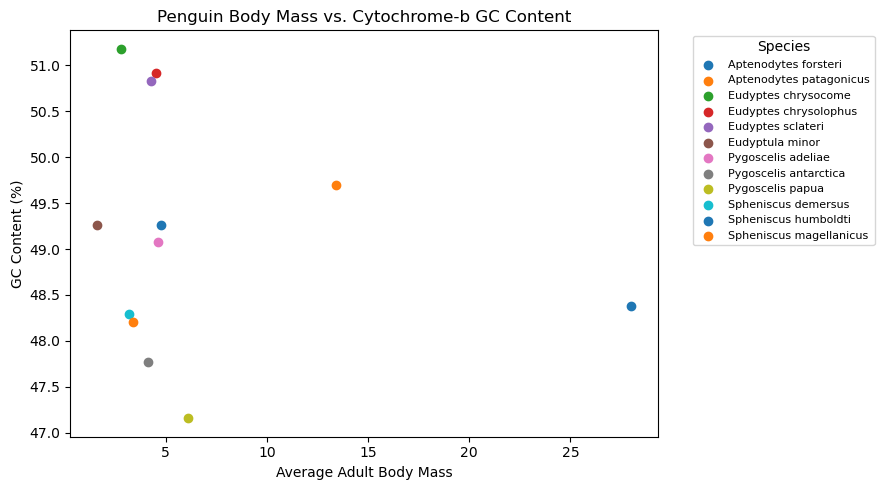

In [121]:
# Create a new figure with a wider width to make space for the legend
plt.figure(figsize=(9, 5))

# Loop through each species in the DataFrame
for species in penguins_df["species"]:
    
    # Select only the row corresponding to the current species
    subset = penguins_df[penguins_df["species"] == species]
    
    # Plot a single point for this species
    # - x-axis: body mass
    # - y-axis: GC content
    # - label: used later in the legend
    plt.scatter(
        subset["mass"],
        subset["GC_content"],
        label=species
    )

# Label the x-axis
plt.xlabel("Average Adult Body Mass")

# Label the y-axis
plt.ylabel("GC Content (%)")

# Add a title to the plot
plt.title("Penguin Body Mass vs. Cytochrome-b GC Content")

# Create a legend showing species names
# bbox_to_anchor shifts the legend outside the plot to the right
# loc="upper left" anchors the legend relative to that position
# fontsize reduces clutter since there are many species
plt.legend(
    title="Species",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

# Adjust layout so labels and legend do not get cut off
plt.tight_layout()

# Save the figure to the output directory
# bbox_inches="tight" ensures the legend outside the plot is included
plt.savefig(
    OUTPUT_DIR / "body_mass_vs_gc_content_colored.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the plot
plt.show()

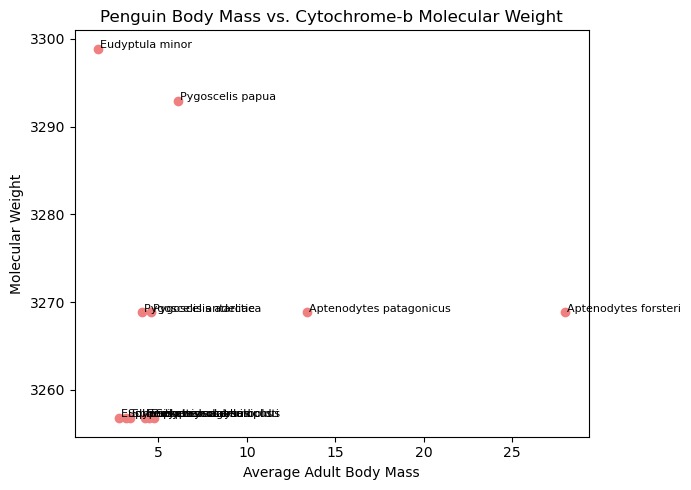

In [122]:
# Plot body mass vs. molecular weight
plt.figure(figsize=(7, 5))
plt.scatter(
    penguins_df["mass"],
    penguins_df["molecular_weight"],
    color="lightcoral"
)

# Annotate each point with species name
for i in range(len(penguins_df)):
    plt.text(
        penguins_df["mass"][i] + 0.1,
        penguins_df["molecular_weight"][i] + 0.1,
        penguins_df["species"][i],
        fontsize=8
    )

plt.xlabel("Average Adult Body Mass")
plt.ylabel("Molecular Weight")
plt.title("Penguin Body Mass vs. Cytochrome-b Molecular Weight")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "body_mass_vs_molecular_weight.png", dpi=300)
plt.show()

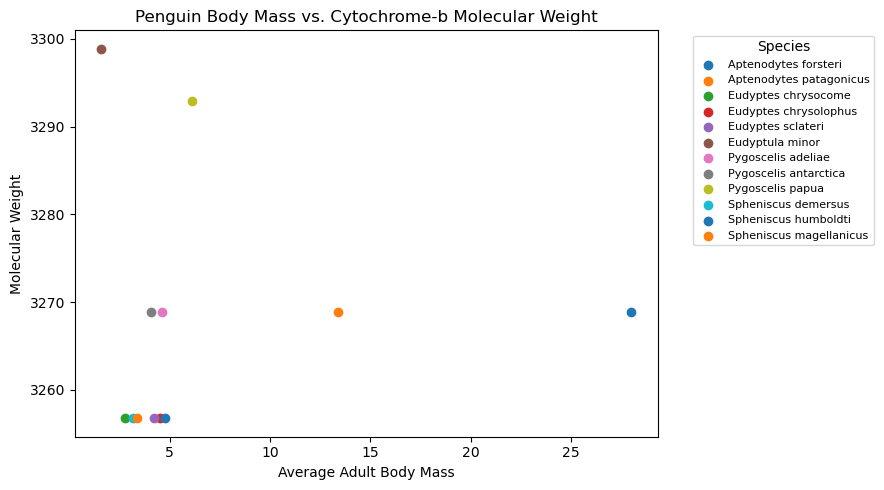

In [123]:
plt.figure(figsize=(9, 5))

for species in penguins_df["species"]:
    subset = penguins_df[penguins_df["species"] == species]
    plt.scatter(
        subset["mass"],
        subset["molecular_weight"],
        label=species
    )

plt.xlabel("Average Adult Body Mass")
plt.ylabel("Molecular Weight")
plt.title("Penguin Body Mass vs. Cytochrome-b Molecular Weight")

plt.legend(
    title="Species",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "body_mass_vs_molecular_weight_colored.png", dpi=300, bbox_inches="tight")
plt.show()